# Ejercicio 1 - Examen 1

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [13]:
tickers = ["AMZN", "JPM", "XOM"]
inicio = "2021-03-03"
fin = "2026-03-03"

precios = yf.download(tickers, start=inicio, end=fin, auto_adjust=True)["Close"]
precios.dropna(inplace=True)
precios

[*********************100%***********************]  3 of 3 completed


Ticker,AMZN,JPM,XOM
Date,,,
2021-03-03,150.250000,134.656601,46.667786
2021-03-04,148.878494,132.587128,48.476044
2021-03-05,150.022995,132.895370,50.309067
2021-03-08,147.597504,134.656601,50.259525
2021-03-09,153.142502,133.705566,49.483379
...,...,...,...
2026-02-24,208.559998,297.299988,149.259995
2026-02-25,210.639999,303.299988,149.059998
2026-02-26,207.919998,306.130005,148.539993


In [14]:
rendimientos = precios.pct_change().dropna()

media_diaria  = rendimientos.mean()
cov_diaria    = rendimientos.cov()

media_anual   = media_diaria * 252
cov_anual     = cov_diaria * 252

print("=== Rendimiento esperado anual por activo ===")
for ticker, ret in media_anual.items():
    print(f"  {ticker}: {ret:.2%}")

print("\n=== Matriz de covarianzas anual ===")
print(cov_anual.round(6))

print("\n=== Correlaciones entre activos ===")
print(rendimientos.corr().round(3))

=== Rendimiento esperado anual por activo ===
  AMZN: 12.77%
  JPM: 18.90%
  XOM: 27.60%

=== Matriz de covarianzas anual ===
Ticker      AMZN       JPM       XOM
Ticker                              
AMZN    0.124066  0.030132  0.011111
JPM     0.030132  0.059302  0.021832
XOM     0.011111  0.021832  0.071238

=== Correlaciones entre activos ===
Ticker   AMZN    JPM    XOM
Ticker                     
AMZN    1.000  0.351  0.118
JPM     0.351  1.000  0.336
XOM     0.118  0.336  1.000


In [15]:
n_portafolios = 10000
n_activos = len(tickers)

resultados = np.zeros((n_portafolios, 3))
pesos_sim  = np.zeros((n_portafolios, n_activos))

for i in range(n_portafolios):

    pesos = np.random.random(n_activos)
    pesos = pesos / pesos.sum()

    ret_p = np.dot(pesos, media_anual)
    riesgo_p = np.sqrt(pesos @ cov_anual.values @ pesos)
    sharpe_p = (ret_p - 0.04) / riesgo_p
    resultados[i] = [ret_p, riesgo_p, sharpe_p]
    pesos_sim[i]  = pesos

df = pd.DataFrame(resultados, columns=["Retorno", "Riesgo", "Sharpe"])
df[tickers] = pesos_sim
df.describe().round(4)

,Retorno,Riesgo,Sharpe,AMZN,JPM,XOM
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,0.1978,0.2193,0.7303,0.3341,0.3294,0.3365
std,0.0233,0.0205,0.1438,0.1793,0.1792,0.1813
min,0.1288,0.1984,0.2545,0.0005,0.0000,0.0001
25%,0.1820,0.2048,0.6364,0.2002,0.1947,0.2024
50%,0.1977,0.2136,0.7469,0.3363,0.3296,0.3361
75%,0.2129,0.2265,0.8484,0.4484,0.4431,0.4526
max,0.2744,0.3489,0.9458,0.9883,0.9703,0.9877


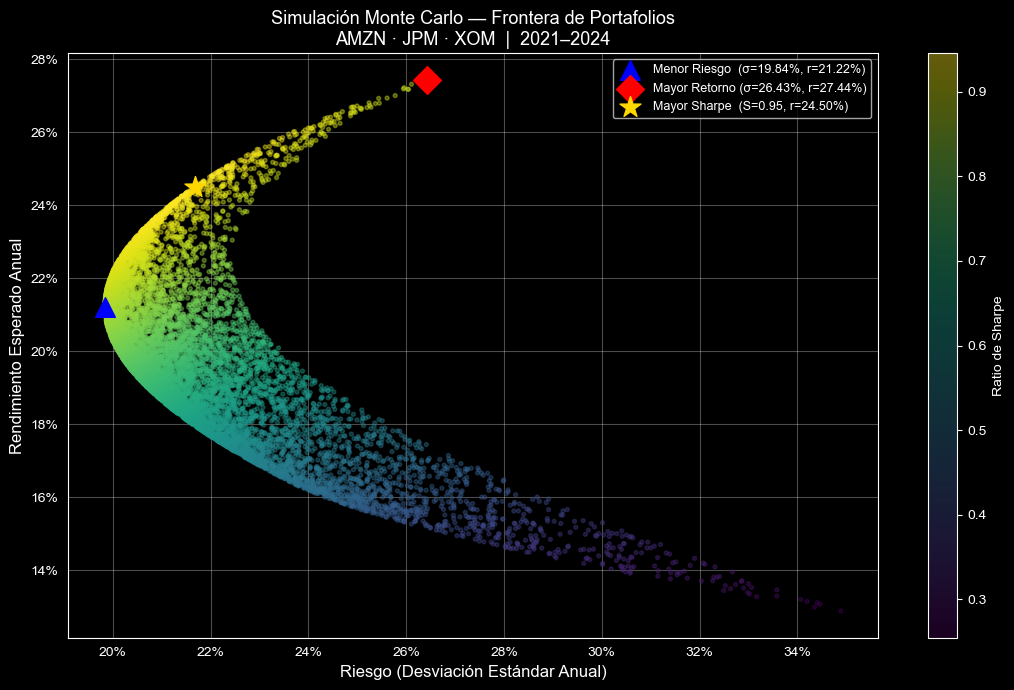


PORTAFOLIO DE MENOR RIESGO
  AMZN: 17.8%  |  JPM: 42.9%  |  XOM: 39.2%
  Retorno: 21.22%  |  Riesgo: 19.84%  |  Sharpe: 0.87

PORTAFOLIO DE MAYOR RETORNO
  AMZN: 0.8%  |  JPM: 0.4%  |  XOM: 98.8%
  Retorno: 27.44%  |  Riesgo: 26.43%  |  Sharpe: 0.89

PORTAFOLIO DE MAYOR SHARPE
  AMZN: 2.4%  |  JPM: 31.6%  |  XOM: 66.0%
  Retorno: 24.50%  |  Riesgo: 21.67%  |  Sharpe: 0.95


In [16]:
idx_min_riesgo  = df["Riesgo"].idxmin()
idx_max_retorno = df["Retorno"].idxmax()
idx_max_sharpe  = df["Sharpe"].idxmax()

p_min_riesgo  = df.loc[idx_min_riesgo]
p_max_retorno = df.loc[idx_max_retorno]
p_max_sharpe  = df.loc[idx_max_sharpe]

fig, ax = plt.subplots(figsize=(11, 7))

sc = ax.scatter(
    df["Riesgo"], df["Retorno"],
    c=df["Sharpe"], cmap="viridis",
    alpha=0.4, s=8
)
plt.colorbar(sc, ax=ax, label="Ratio de Sharpe")

ax.scatter(p_min_riesgo["Riesgo"], p_min_riesgo["Retorno"],
           color="blue", s=200, zorder=5, marker="^",
           label=f"Menor Riesgo  (σ={p_min_riesgo['Riesgo']:.2%}, r={p_min_riesgo['Retorno']:.2%})")

ax.scatter(p_max_retorno["Riesgo"], p_max_retorno["Retorno"],
           color="red", s=200, zorder=5, marker="D",
           label=f"Mayor Retorno (σ={p_max_retorno['Riesgo']:.2%}, r={p_max_retorno['Retorno']:.2%})")

ax.scatter(p_max_sharpe["Riesgo"], p_max_sharpe["Retorno"],
           color="gold", s=250, zorder=5, marker="*",
           label=f"Mayor Sharpe  (S={p_max_sharpe['Sharpe']:.2f}, r={p_max_sharpe['Retorno']:.2%})")

ax.set_xlabel("Riesgo (Desviación Estándar Anual)", fontsize=12)
ax.set_ylabel("Rendimiento Esperado Anual", fontsize=12)
ax.set_title("Simulación Monte Carlo — Frontera de Portafolios\nAMZN · JPM · XOM  |  2021–2024", fontsize=13)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("frontera_eficiente.png", dpi=150)
plt.show()

print("\n" + "="*55)
print("PORTAFOLIO DE MENOR RIESGO")
print(f"  AMZN: {p_min_riesgo['AMZN']:.1%}  |  JPM: {p_min_riesgo['JPM']:.1%}  |  XOM: {p_min_riesgo['XOM']:.1%}")
print(f"  Retorno: {p_min_riesgo['Retorno']:.2%}  |  Riesgo: {p_min_riesgo['Riesgo']:.2%}  |  Sharpe: {p_min_riesgo['Sharpe']:.2f}")

print("\nPORTAFOLIO DE MAYOR RETORNO")
print(f"  AMZN: {p_max_retorno['AMZN']:.1%}  |  JPM: {p_max_retorno['JPM']:.1%}  |  XOM: {p_max_retorno['XOM']:.1%}")
print(f"  Retorno: {p_max_retorno['Retorno']:.2%}  |  Riesgo: {p_max_retorno['Riesgo']:.2%}  |  Sharpe: {p_max_retorno['Sharpe']:.2f}")

print("\nPORTAFOLIO DE MAYOR SHARPE")
print(f"  AMZN: {p_max_sharpe['AMZN']:.1%}  |  JPM: {p_max_sharpe['JPM']:.1%}  |  XOM: {p_max_sharpe['XOM']:.1%}")
print(f"  Retorno: {p_max_sharpe['Retorno']:.2%}  |  Riesgo: {p_max_sharpe['Riesgo']:.2%}  |  Sharpe: {p_max_sharpe['Sharpe']:.2f}")

## Análisis y Recomendación de Portafolio

Se simularon 10,000 portafolios combinando AMZN, JPM y XOM durante 2021–2026.

| Portafolio   | AMZN  | JPM   | XOM   | Retorno | Riesgo | Sharpe |
|--------------|-------|-------|-------|---------|--------|--------|
| Menor Riesgo | 17.8% | 42.9% | 39.2% | 21.22%  | 19.84% | 0.87   |
| Mayor Retorno | 0.8%  | 0.4%  | 98.8% | 27.44%  | 26.43% | 0.89   |
| Mayor Sharpe | 2.4%  | 31.6% | 66.0% | 24.50%  | 21.67% | 0.95   |

### Recomendación: Portafolio de Mayor Sharpe

Se recomienda el portafolio de **mayor Ratio de Sharpe** (JPM 31.6% + XOM 66.0%),
ya que ofrece el mejor rendimiento ajustado por riesgo.

Con solo 1.83% más de riesgo que el portafolio más conservador, genera
3.28% adicional de retorno anual, un intercambio muy favorable. A diferencia
del portafolio de mayor retorno, evita concentrar casi todo el capital en un
solo activo (XOM 98.8%), manteniendo una diversificación razonable.

A lo mejor también seria bueno hacer una optimización de portafolio utilizando otras tecnicas y estrategias vistas en nuestra clase de portafolios de inversión, ya que en la vida real nada de esto se utiliza sinceramente. Sino que se usan otras simulaciones y otros procesos para encontrar portafolios optimos dependiendo la necesidad y las caracteristicas de la persona.